# Density Comparison — Papers vs Teams

Kernel-density estimate of each corpus over the shared joint-UMAP space, plotted
as `log2(teams_density / papers_density)`:

- **Red** = teams-dense relative to papers (iGEM activity ahead of the literature)
- **Blue** = papers-dense relative to teams (literature not yet adopted by iGEM)
- **White/neutral** = balanced coverage

This notebook also computes the **temporal precedence** of overlap-zone topics and
saves the tables consumed by `06-deliverables`.

> Run `03-compute_coords.ipynb` first.

In [1]:
# ── Make the shared aux/ package importable ───────────────────────────────────
# These notebooks live in 05-reporting/ alongside the aux/ package.
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

In [2]:
import matplotlib.pyplot as plt

from aux.paths import REPORTS_DIR, set_seed
from aux.coords import load_plot_data
from aux.density import (
    compute_density_ratio, draw_density_heatmap, topic_zones,
    curated_density_labels, dfprec_extreme_labels,
)
from aux.labels import add_density_labels
from aux.precedence import compute_precedence, save_precedence

set_seed()
df_papers, df_teams, XLIM, YLIM = load_plot_data()
papers_xy = df_papers[["x", "y"]].to_numpy()
teams_xy = df_teams[["x", "y"]].to_numpy()
print(f"Papers: {len(df_papers):,} | Teams: {len(df_teams):,}")

Papers: 19,017 | Teams: 3,811


## 1. Density-ratio grid

In [3]:
dens = compute_density_ratio(papers_xy, teams_xy, XLIM, YLIM, grid_res=300, bw=0.15)
print(f"Grid {dens['grid_res']}x{dens['grid_res']}, ratio clipped to ±{dens['vmax']:.2f}")

Grid 300x300, ratio clipped to ±20.21


## 2. Density-ratio heatmap (curated labels)

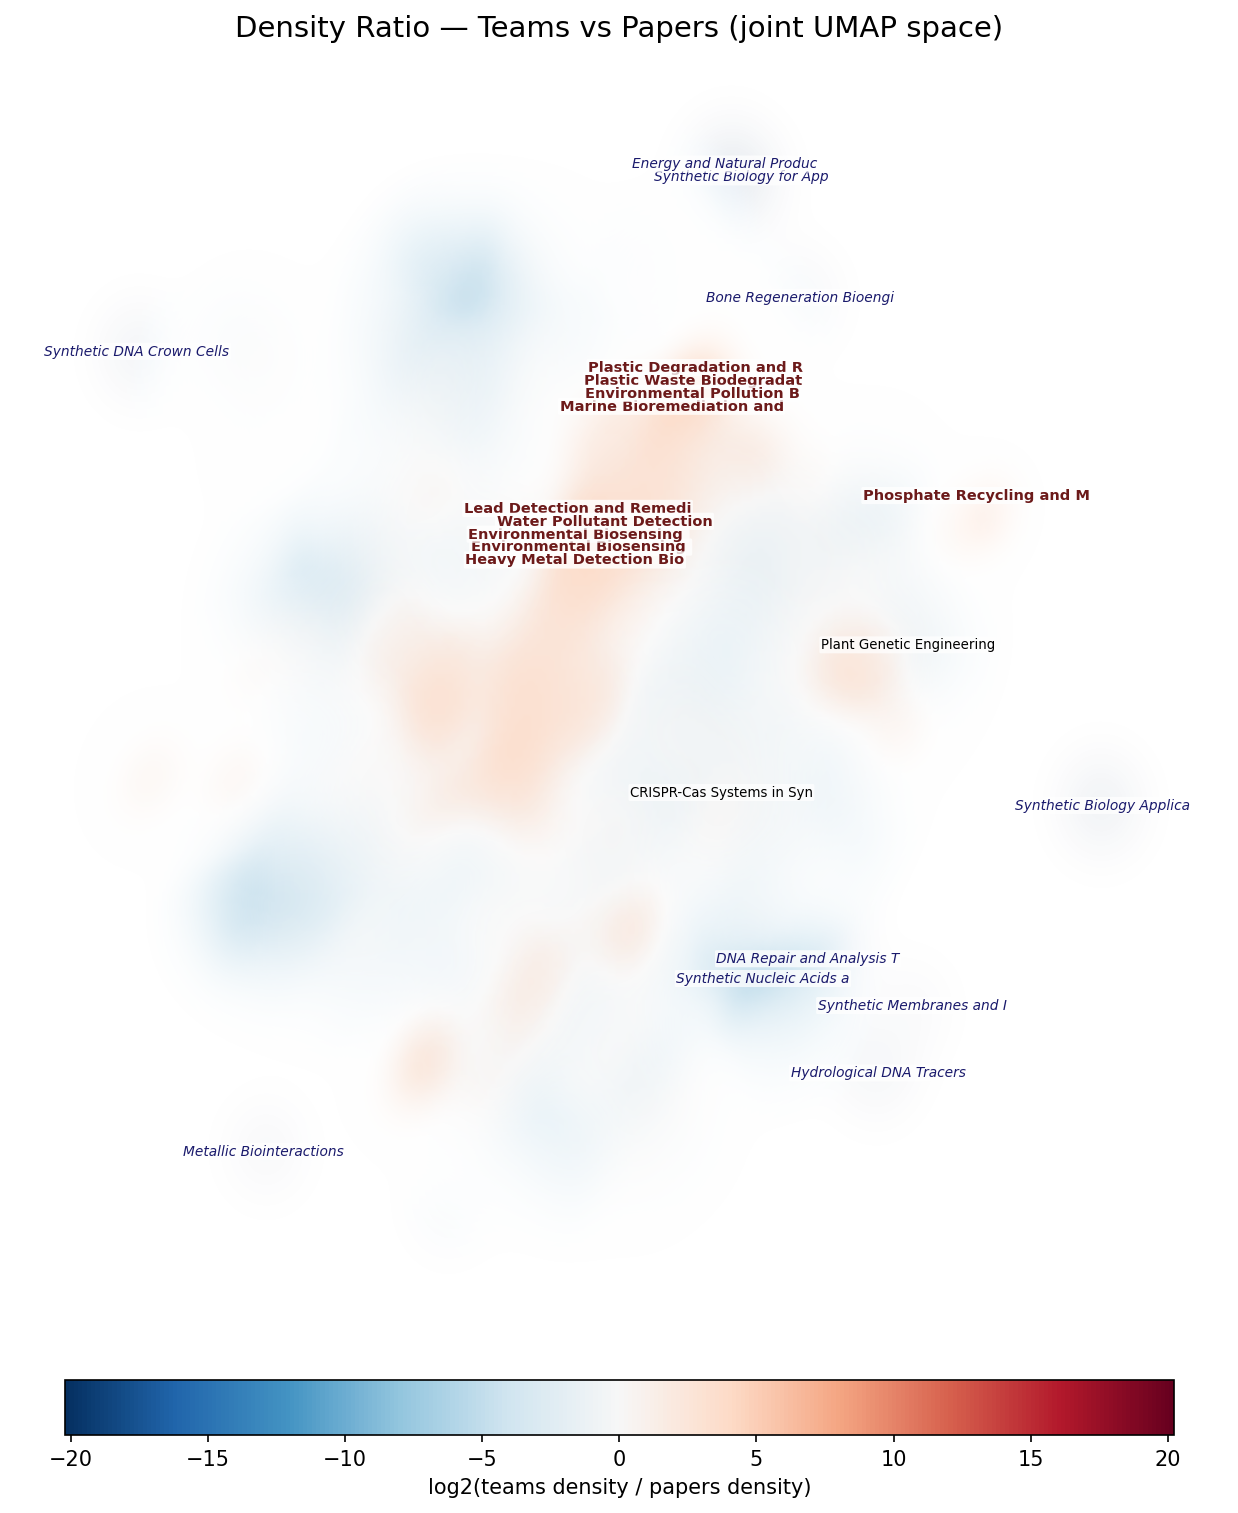

In [4]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
draw_density_heatmap(ax, dens, XLIM, YLIM)

papers_ctr = topic_zones(df_papers, "topic", "low_name", dens["ratio_interp"])
teams_ctr = topic_zones(df_teams, "topic", "low_name", dens["ratio_interp"])
add_density_labels(ax, curated_density_labels(papers_ctr, teams_ctr, n=10), XLIM, YLIM)

ax.set_title("Density Ratio — Teams vs Papers (joint UMAP space)", fontsize=14)
fig.savefig(REPORTS_DIR / "umap_density_ratio.png", dpi=220, bbox_inches="tight")
plt.show()

## 3. Temporal precedence of overlap topics

For each overlap-zone paper topic, find the teams nearby in the joint space and
compare year distributions. `delta_*_years < 0` → iGEM teams preceded the
literature; `> 0` → the literature preceded iGEM.

In [5]:
df_prec, papers_ctr, teams_ctr = compute_precedence(df_papers, df_teams, dens["ratio_interp"])
igem, lit = save_precedence(df_prec)

print("Papers topics by zone:", papers_ctr["zone"].value_counts().to_dict())
print(f"Overlap topics: {len(df_prec)} | iGEM-first: {len(igem)} | literature-first: {len(lit)}")
print(f"Saved → {REPORTS_DIR}: overlap_precedence_full.tsv, igem_preceded.tsv, literature_preceded.tsv")
df_prec.head(10)

Papers topics by zone: {'papers-only': 112, 'overlap': 82, 'teams-dominant': 31}
Overlap topics: 74 | iGEM-first: 47 | literature-first: 27
Saved → /Users/cristian/Desktop/GitHub/igem-synbio/assets/reports: overlap_precedence_full.tsv, igem_preceded.tsv, literature_preceded.tsv


,topic,global_name,n_papers,n_nearby_teams,papers_min_year,papers_p5_year,papers_q1_year,papers_mean_year,papers_median_year,papers_q3_year,...,teams_median_year,teams_q3_year,teams_max_year,delta_min_years,delta_p5_years,delta_q1_years,delta_mean_years,delta_median_years,delta_q3_years,delta_max_years
0,127,Genetic Logic and Memory Devices,36,19,2008.0,2011.0,2014.00,2017.86,2018.5,2022.00,...,2008.0,2012.00,2024.0,-3.0,-5.10,-7.00,-7.75,-10.5,-10.00,-1.0
1,222,Viral Vector Engineering,20,3,2008.0,2017.5,2019.75,2021.65,2022.5,2024.25,...,2010.0,2017.00,2024.0,1.0,-8.40,-10.25,-7.32,-12.5,-7.25,-1.0
2,178,Microbial Stress Tolerance,25,4,2005.0,2008.6,2014.00,2018.40,2018.0,2023.00,...,2011.5,2013.50,2018.0,3.0,-0.15,-3.75,-6.15,-6.5,-9.50,-7.0
3,142,Ribosome Engineering,33,6,2009.0,2011.6,2015.00,2019.45,2020.0,2023.00,...,2011.5,2012.75,2025.0,0.0,-2.35,-4.75,-6.12,-8.5,-10.25,0.0
4,113,Microbial Community Design,39,3,2007.0,2010.0,2013.50,2017.67,2018.0,2022.00,...,2011.0,2014.50,2018.0,0.0,-2.60,-4.50,-5.67,-7.0,-7.50,-7.0
5,220,Microfluidics in Synthetic Biology,20,3,2012.0,2012.0,2017.00,2019.25,2019.5,2021.25,...,2009.0,2016.50,2024.0,-4.0,-3.90,-8.50,-5.58,-10.5,-4.75,-1.0
6,184,Cofactor and Enzyme Engineering,25,6,2011.0,2011.0,2019.00,2020.60,2021.0,2025.00,...,2016.0,2017.50,2018.0,-2.0,-0.50,-3.75,-5.27,-5.0,-7.50,-7.0
7,131,Cell-Free Genome Engineering,35,19,2005.0,2007.7,2013.50,2017.94,2019.0,2022.50,...,2012.0,2015.00,2023.0,2.0,0.20,-3.50,-5.26,-7.0,-7.50,-2.0
8,149,Microbial Genome Editing,31,6,2011.0,2011.0,2015.00,2018.10,2019.0,2021.50,...,2013.0,2014.00,2018.0,-1.0,-0.75,-3.75,-4.93,-6.0,-7.50,-7.0
9,213,Reaction-Diffusion Pattern Formation,21,13,2011.0,2013.0,2015.00,2018.24,2018.0,2021.00,...,2015.0,2016.00,2019.0,-4.0,-5.40,-4.00,-4.78,-3.0,-5.00,-6.0


## 4. Density-ratio heatmap (precedence extremes)

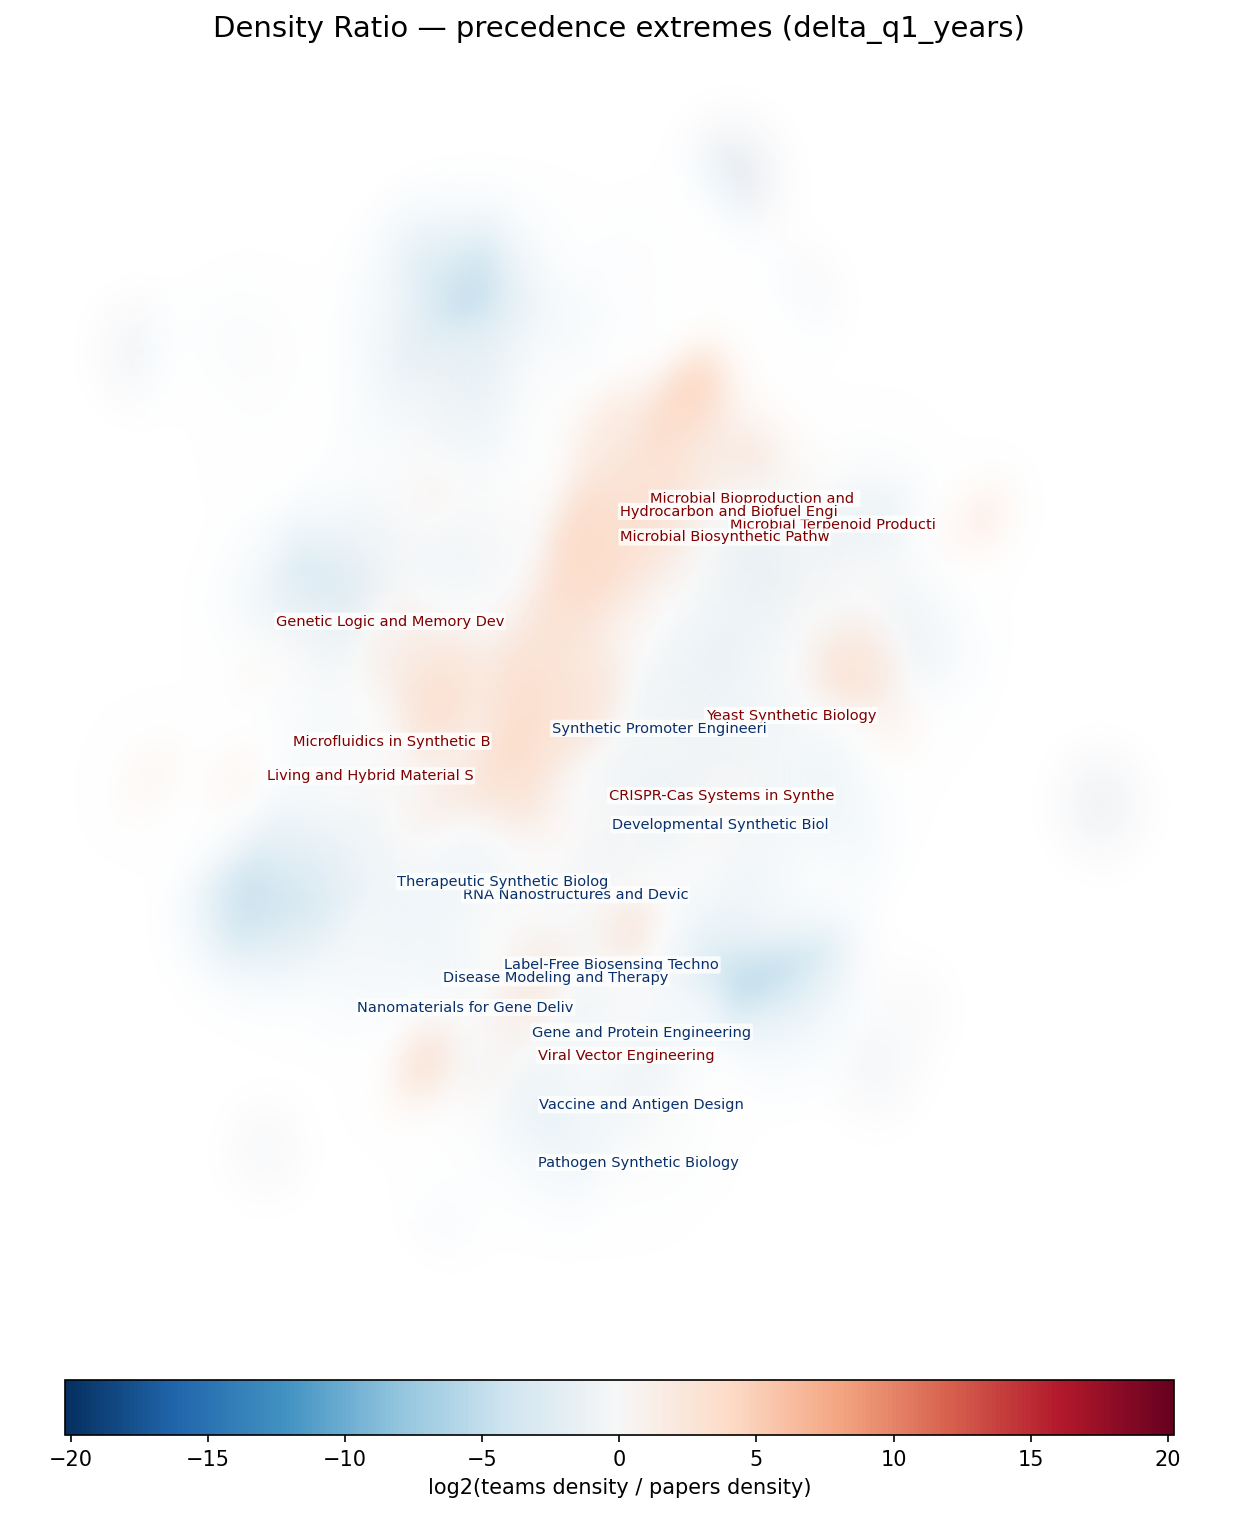

In [6]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
draw_density_heatmap(ax, dens, XLIM, YLIM)
add_density_labels(ax, dfprec_extreme_labels(df_prec, papers_ctr, n_extreme=10), XLIM, YLIM)

ax.set_title("Density Ratio — precedence extremes (delta_q1_years)", fontsize=14)
fig.savefig(REPORTS_DIR / "umap_density_ratio_extremes.png", dpi=220, bbox_inches="tight")
plt.show()